# Распаковка файлов

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
%cd /content/celeba/pred

/content/celeba/pred


In [11]:
!unzip /content/celeba/pred/pred.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: 045389.jpg              
  inflating: 147700.jpg              
  inflating: 065422.jpg              
  inflating: 179858.jpg              
  inflating: 082462.jpg              
  inflating: 172233.jpg              
  inflating: 075628.jpg              
  inflating: 010523.jpg              
  inflating: 000680.jpg              
  inflating: 014049.jpg              
  inflating: 175533.jpg              
  inflating: 108836.jpg              
  inflating: 028754.jpg              
  inflating: 018921.jpg              
  inflating: 004682.jpg              
  inflating: 089469.jpg              
  inflating: 117806.jpg              
  inflating: 085797.jpg              
  inflating: 001369.jpg              
  inflating: 096299.jpg              
  inflating: 131137.jpg              
  inflating: 021616.jpg              
  inflating: 160614.jpg              
  inflating: 113588.jpg              
  inflating: 076240.

In [12]:
PROJECT_DIR = Path("/content/celeba")

ALIGNED_CSV = PROJECT_DIR / "aligned_faces_predicted.csv"

PRED_DIR = PROJECT_DIR / "pred"

In [13]:
df = pd.read_csv(ALIGNED_CSV)
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,lefteye_x_pred,lefteye_y_pred,righteye_x_pred,righteye_y_pred,nose_x_pred,nose_y_pred,leftmouth_x_pred,leftmouth_y_pred,rightmouth_x_pred,rightmouth_y_pred
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,40.0,46.0,86.0,44.0,58.0,72.0,54.0,82.0,98.0,78.0
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,40.0,46.0,86.0,46.0,54.0,68.0,42.0,82.0,88.0,82.0
2,000015.jpg,1,-1,-1,1,-1,-1,-1,1,-1,...,40.0,46.0,84.0,40.0,72.0,62.0,56.0,82.0,94.0,74.0
3,000018.jpg,-1,1,-1,-1,-1,-1,-1,1,-1,...,40.0,46.0,94.0,48.0,64.0,68.0,38.0,82.0,90.0,84.0
4,000088.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,40.0,46.0,76.0,40.0,54.0,62.0,54.0,78.0,78.0,74.0


У меня в этом ноутбуке изменились чуть пути к файлам, переделала:

In [14]:
!find /content -type f -name "000033.jpg"

In [15]:
print(df["aligned_path"].iloc[0])

/content/celeba/prepared_data/aligned_faces/pred/000001.jpg


In [16]:
old_root = "/content/celeba/prepared_data/aligned_faces/pred"
new_root = "/content/celeba/pred"

df["aligned_path"] = df["aligned_path"].str.replace(
    old_root,
    new_root,
    regex=False
)

# Подготовка датасета

## Label Encoder

Каждому человеку какое-то значение присваиваю с помощью `LabelEncoder()` для CrossEntropyLoss

In [17]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["identity_id"])

In [18]:
num_classes = df["label"].nunique()

In [19]:
print("Число изображений:", len(df))
print("Число классов:", num_classes)
print(df["label"].value_counts().describe())

Число изображений: 15017
Число классов: 500
count    500.000000
mean      30.034000
std        0.324121
min       30.000000
25%       30.000000
50%       30.000000
75%       30.000000
max       35.000000
Name: count, dtype: float64


## train test split


In [20]:
# сохраняю пропорции
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True, stratify=df["label"])

In [21]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [22]:
print(train_df.shape, val_df.shape)
print("train classes:", train_df["label"].nunique())
print("val classes:", val_df["label"].nunique())

(12013, 80) (3004, 80)
train classes: 500
val classes: 500


# ResNet18

## Dataset, Dataloader

Подготавливаю датасет для обучения. Я добавила аугментацию: половину фото в тренировочной выборке отзеркалила, т. к. личность не меняется от отражения

In [23]:
from torchvision import transforms

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.1
        )
    ], p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet mean, std
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [25]:
class FaceRecognitionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["aligned_path"]).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(row["label"], dtype=torch.long)

        return img, label

In [26]:
batch_size = 64

In [27]:
train_dataset = FaceRecognitionDataset(train_df, transform=train_transform)
val_dataset = FaceRecognitionDataset(val_df, transform=val_transform)

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [29]:
from pathlib import Path

df["file_exists"] = df["aligned_path"].apply(lambda p: Path(p).exists())

In [30]:
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,righteye_x_pred,righteye_y_pred,nose_x_pred,nose_y_pred,leftmouth_x_pred,leftmouth_y_pred,rightmouth_x_pred,rightmouth_y_pred,label,file_exists
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,86.0,44.0,58.0,72.0,54.0,82.0,98.0,78.0,124,True
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,86.0,46.0,54.0,68.0,42.0,82.0,88.0,82.0,130,True
2,000015.jpg,1,-1,-1,1,-1,-1,-1,1,-1,...,84.0,40.0,72.0,62.0,56.0,82.0,94.0,74.0,69,True
3,000018.jpg,-1,1,-1,-1,-1,-1,-1,1,-1,...,94.0,48.0,64.0,68.0,38.0,82.0,90.0,84.0,96,True
4,000088.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,76.0,40.0,54.0,62.0,54.0,78.0,78.0,74.0,287,True


In [31]:
imgs, labels = next(iter(train_loader))
imgs.shape, labels.shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## Модель

Сначала я взяла попробовать ResNet18

In [32]:
from torchvision.models import resnet18, ResNet18_Weights

In [33]:
class FaceEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512, pretrained=True):
        super().__init__()

        weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = resnet18(weights=weights)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity() # убираю последний слой с классификацией изображений

        self.backbone = backbone

        self.embedding = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
        )

    def forward(self, x):
        x = self.backbone(x)
        emb = self.embedding(x)
        return emb

Классификатор для Cross Entropy:

In [34]:
class FaceClassifierCE(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, pretrained=True):
        super().__init__()

        self.embedding_model = FaceEmbeddingModel(
            embedding_dim=embedding_dim,
            pretrained=pretrained,
        )

        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        emb = self.embedding_model(x)
        logits = self.classifier(emb)
        return logits

## Функции обучения и валидации

Функция подсчета accuracy:

In [35]:
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

Обучение на одной эпохе:

In [36]:
def train_one_epoch_ce(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(imgs)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = imgs.size(0)

        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, labels) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

In [37]:
@torch.no_grad()
def evaluate_ce(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        batch_size = imgs.size(0)

        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, labels) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

## Обучение

In [38]:
ce_model = FaceClassifierCE(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=True,
).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [39]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    ce_model.parameters(),
    lr=1e-4,
    weight_decay=1e-3,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

In [40]:
num_epochs = 12

history_ce = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

In [ ]:
best_val_acc = 0.0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch_ce(ce_model, train_loader, optimizer, criterion, device)

    val_loss, val_acc = evaluate_ce(ce_model, val_loader, criterion, device)

    scheduler.step(val_acc)

    history_ce["train_loss"].append(train_loss)
    history_ce["train_acc"].append(train_acc)
    history_ce["val_loss"].append(val_loss)
    history_ce["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ce_model.state_dict(), PROJECT_DIR / "ce_resnet18_best.pt")

100%|██████████| 47/47 [00:07<00:00,  5.96it/s]


Epoch 01/12 | train_loss=5.6380 | train_acc=0.0777 | val_loss=4.9471 | val_acc=0.1964


100%|██████████| 47/47 [00:07<00:00,  6.17it/s]


Epoch 02/12 | train_loss=4.3224 | train_acc=0.3638 | val_loss=4.0499 | val_acc=0.4211


100%|██████████| 47/47 [00:06<00:00,  6.98it/s]


...

Epoch 10/12 | train_loss=1.1015 | train_acc=0.9991 | val_loss=2.0808 | val_acc=0.8096


100%|██████████| 47/47 [00:14<00:00,  3.23it/s]


Epoch 11/12 | train_loss=1.0875 | train_acc=0.9992 | val_loss=2.0639 | val_acc=0.8103


100%|██████████| 47/47 [00:15<00:00,  3.10it/s]


Epoch 12/12 | train_loss=1.0737 | train_acc=0.9994 | val_loss=2.0484 | val_acc=0.8159


# EfficientNet-B0

Ради интереса решила попробовать EfficientNet-B0

## Dataset and Dataloader

In [41]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [42]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.03,
        )
    ], p=0.5),
    transforms.RandomRotation(degrees=5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [43]:
class FaceRecognitionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["aligned_path"]).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(row["label"], dtype=torch.long)

        return img, label

In [44]:
train_dataset = FaceRecognitionDataset(train_df, transform=train_transform)
val_dataset = FaceRecognitionDataset(val_df, transform=val_transform)

In [45]:
batch_size = 64

In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

## Модель

In [5]:
class EfficientNetEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512, pretrained=True):
        super().__init__()

        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        backbone = efficientnet_b0(weights=weights)

        in_features = backbone.classifier[1].in_features

        # убираю ImageNet классификатор
        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.embedding = nn.Sequential(
            nn.Linear(in_features, embedding_dim, bias=False),
            nn.BatchNorm1d(embedding_dim),
            nn.Dropout(p=0.3),
        )

    def forward(self, x):
        x = self.backbone(x)
        emb = self.embedding(x)
        return emb

Классификатор для Cross Entropy:

In [6]:
class EfficientNetClassifierCE(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, pretrained=True):
        super().__init__()

        self.embedding_model = EfficientNetEmbeddingModel(
            embedding_dim=embedding_dim,
            pretrained=pretrained,
        )

        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        emb = self.embedding_model(x)
        logits = self.classifier(emb)
        return logits

## Функции обучения и валидации

Я добавила clip_grad_norm_, чтобы обучение было стабильнее

In [47]:
def train_one_epoch_ce(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(imgs)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        batch_size = imgs.size(0)

        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, labels) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

In [48]:
@torch.no_grad()
def evaluate_ce(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        batch_size = imgs.size(0)

        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, labels) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

## Обучение

In [49]:
ce_model = EfficientNetClassifierCE(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=True,
).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


In [50]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [51]:
optimizer = torch.optim.AdamW(
    ce_model.parameters(),
    lr=1e-4,
    weight_decay=1e-3,
)

In [52]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

Цикл обучения:

In [53]:
num_epochs = 16

history_ce = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

In [ ]:
best_val_acc = 0.0
best_model_path = PROJECT_DIR / "ce_efficientnet_b0_best.pt"

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch_ce(
        ce_model,
        train_loader,
        optimizer,
        criterion,
        device,
    )

    val_loss, val_acc = evaluate_ce(
        ce_model,
        val_loader,
        criterion,
        device,
    )

    scheduler.step(val_acc)

    history_ce["train_loss"].append(train_loss)
    history_ce["train_acc"].append(train_acc)
    history_ce["val_loss"].append(val_loss)
    history_ce["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ce_model.state_dict(), best_model_path)

100%|██████████| 47/47 [00:16<00:00,  2.79it/s]


Epoch 01/16 | train_loss=6.0947 | train_acc=0.0156 | val_loss=5.5292 | val_acc=0.0789


100%|██████████| 47/47 [00:16<00:00,  2.93it/s]


Epoch 02/16 | train_loss=5.1674 | train_acc=0.1253 | val_loss=4.7486 | val_acc=0.2270


100%|██████████| 47/47 [00:16<00:00,  2.82it/s]


...

Epoch 14/16 | train_loss=1.1847 | train_acc=0.9942 | val_loss=1.9603 | val_acc=0.8066


100%|██████████| 47/47 [00:17<00:00,  2.68it/s]


Epoch 15/16 | train_loss=1.1563 | train_acc=0.9968 | val_loss=1.9456 | val_acc=0.8159


100%|██████████| 47/47 [00:16<00:00,  2.77it/s]

Epoch 16/16 | train_loss=1.1451 | train_acc=0.9976 | val_loss=1.9512 | val_acc=0.8119


## Графики лосса и accuracy

Лосс:

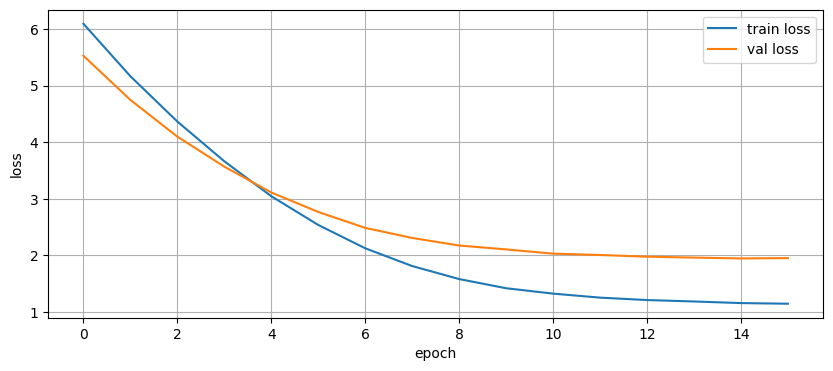

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_ce["train_loss"], label="train loss")
plt.plot(history_ce["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid()
plt.show()

accuracy:

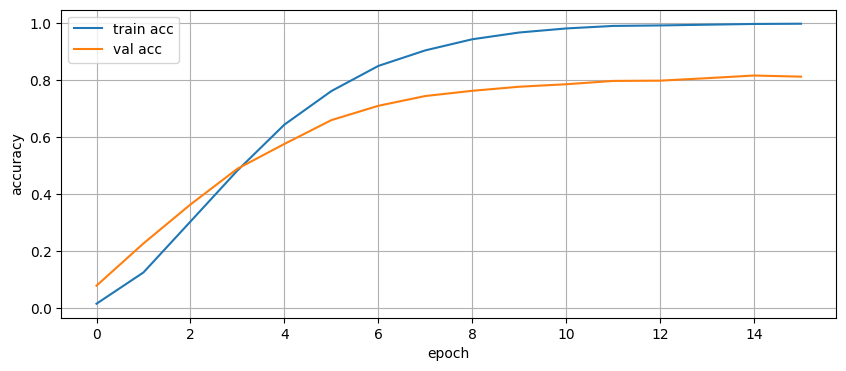

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_ce["train_acc"], label="train acc")
plt.plot(history_ce["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid()
plt.show()

Я дальше при рассмотрении ArcFace взяла именно EfficientNet-B0.

# ArcFace

## Теория

**Как устроен ArcFace**:

Стандартные SoftMax + кросс-энтропия (CE) выглядят так:

$$L_{CE} = \frac{-1}{N}\sum_1^N \frac{e^{W_{y_i}^{T}x_i + b_{y_i}}}{\sum^n_{j=1}e^{W_j^Tx_i+b_j}},$$

здесь:
- $x_i \in \mathbb{R^d}$ — вектор $i$-го элемента обучающей выборки перед последним полносвязным слоем сети. $y_i$ — класс этого элемента;
- $W_j \in \mathbb{R^d}$ — j-ый столбец матрицы весов последнего слоя сети (т.е. слоя, который производит итоговую классификацю входящего объекта);
- $b_j \in \mathbb{R^d}$ — j-ый элемент вектора байеса последнего слоя сети;
- $N$ — batch size;
- $n$ — количество классов.


Хотя этот лосс работает хорошо, он явным образом не заставляет эмбеддинги $x_i$ элементов, принадлежащих одному классу, быть близкими друг к другу по расстоянию. И не заставляет эмбеддинги элементов, принадлежащих разным классам, быть далеко друг от друга. Все, что хочет этот лосс — чтобы на основе эмбеддингов $x_i$ можно было хорошо классифицировать элементы, никакие ограничений на расстояния между эмбеддингами $x_i$ он не вводит.

Из-за этого у нейросетей для распознавания лиц, которые обучены на обычном CE loss, бывают проблемы с распознаванием лиц, которые сильно отличаются от лиц того же человека разными доп. атрибутами (шляпа/прическа/очки и т.п.). Просто эмбеддинг для таких лиц получается довольно далек по расстоянию от других эмбеддингов лиц этого же человека.

Давайте теперь немного поправим формулу:
- уберем байес последнего слоя, т.е. сделаем $b_j=0$;
- нормализуем веса последнего слоя: ||$W_j$|| = 1;
- нормализуем эмбеддинги: ||$x_i$|| = 1. Перед подачей их на вход последнему слою (т.е. перед умножением на матрицу $W_j$) умножим их на гиперпараметр s. По сути, мы приводим норму всех эмбеддингов к s. Смысл этого гиперпараметра в том, что, возможно, сети проще будет классифицировать эмбеддинги, у которых не единичная норма.

Нормализация приводит к тому, что эмбеддинги распределяются по сфере единичного радиуса (и сфере радиуса s после умножения на гиперпараметр s). И итоговые предсказания сети после последнего слоя зависят только от угла между эмбеддингами $x_i$ и выученных весов $W_j$. От нормы эмбеддинга $x_i$ они больше не зависят, т.к. у всех эмбеддингов они теперь одинаковые.

Получается, в степени экспоненты у нас останется выражение $s W_{y_i}^{T}x_i$, которое можно переписать в виде  $s W_{y_i}^{T}x_i = s ||W_{y_i}||\cdot ||x_i|| \cdot cos\Theta_{y_i}$. Тут $\Theta_{y_i}$ — это угол между векторами $W_{y_i}$ и $x_i$. Но так как мы сделали нормы $W_{y_i}$ и $x_i$ единичными, то все это выражение просто будет равно $s cos\Theta_{y_i}$.

В итоге мы получим следующую формулу лосса:

$$L = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos\Theta_{y_i}}}{e^{s\ cos\Theta_{y_i}} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$


И последний шаг. Добавим еще один гиперпараметр $m$. Он называется additive angular margin penalty и заставляет эмбеддинги одного класса быть ближе друг к другу, а эмбеддинги разных классов — более далекими друг от друга.

В итоге получим вот что:

$$L_{ArcFace} = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos(\Theta_{y_i} + m)}}{e^{s\ cos(\Theta_{y_i} + m)} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$

Это и есть ArcFace Loss с двумя  гиперпараметрами, s и m.

Получается, что ArcFace Loss завтавляет сеть выучивать эмбеддинги, распределенные по сфере радиуса s, причем чтобы эмбеддинги одного класса были ближе друг к другу, а эмбеддинги разных классов — более далеки друг от друга.

![ArcFace](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTKRR-YA_XR3yhIYBbkc8Zlbua0Q2WdM3gx_g&s)

**Важное пояснение:**

Строго говоря, ArcFace - не лосс, отдельный архитектурный модуль модификация SoftMax. Он реализует идею внесения геометрического отступа непосредственно в пространство признаков. Для обучения в качестве лосса используется обычная кросс-энтропия. Более конкретно по шагам:

1. Вы извлекаете эмбеддинги из бэкбона сети (предобученной модели, у которой обрезан FC-слой, если он был)
2. Эти эмбеддинги поступают в ArcFace-слой, который содержит векторы-центры для каждого класса (веса классификатора) и логику нормализации и добавления углового отступа
3. Для целевого класса ArcFace-слой преобразует косинус угла $\theta$ в $cos(\theta + m)$
4. Для остальных классов оставляет обычный косинус $cos(\theta)$
5. Эти модифицированные логиты подаются на вход стандартной функции Cross-Entropy
6. Градиенты от Cross-Entropy текут назад через ArcFace-слой к бэкбону, обучая модель извлекать эмбеддинги

Результат: модифицированные логиты с "жестким" разделением для целевого класса, а значит и более качественные эмбеддинги.

Схема:
```
[Изображение] → [Бэкбон] → [ЭМБЕДДИНГ] → [ArcFace] → [Логиты] → [CE Loss]
                    │                        │           │          
                   CNN                   Нормализация   Оценки
                                          + Angular    для всех
                                            Margin     классов
```

Для получения качественных эмбеддингов после обучения ArcFace-слой больше не нужен, и его обычно обрезают. Он нужен был только обучения модели, и поэтому часто ArcFace называю именно лоссом. Но стоит всегда держать в голове, что это некоторое упрощение, которое нужно лишь для того, чтобы проще формулировать мысли.

Заменяю обычный Linear-классификатор на ArcFace layer:

## ArcFaceLayer

In [54]:
import math

class ArcFaceLayer(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.2):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        # нормализую embeddings и веса классов
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weights = F.normalize(self.weight, p=2, dim=1)

        # cos(theta)
        cosine = F.linear(embeddings, weights)

        # sin(theta)
        sine = torch.sqrt(torch.clamp(1.0 - cosine ** 2, min=1e-7))

        # cos(theta + m)
        phi = cosine * self.cos_m - sine * self.sin_m

        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = one_hot * phi + (1.0 - one_hot) * cosine

        # умножаю на масштаб
        logits *= self.s

        return logits

In [55]:
class EfficientNetClassifierArcFace(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, pretrained=True):
        super().__init__()

        self.embedding_model = EfficientNetEmbeddingModel(
            embedding_dim=embedding_dim,
            pretrained=pretrained,
        )

        self.arcface = ArcFaceLayer(
            in_features=embedding_dim,
            out_features=num_classes,
            s=30.0,
            m=0.2,
        )

    def forward(self, x, labels=None):
        embeddings = self.embedding_model(x)

        if labels is None:
            return embeddings

        logits = self.arcface(embeddings, labels)
        return logits

In [56]:
ce_model = EfficientNetClassifierCE(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=True,
).to(device)

ce_model.load_state_dict(
    torch.load(PROJECT_DIR / "ce_efficientnet_b0_best.pt", map_location=device)
)

<All keys matched successfully>

In [57]:
arc_model = EfficientNetClassifierArcFace(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=True,
).to(device)

arc_model.embedding_model.load_state_dict(
    ce_model.embedding_model.state_dict()
)

<All keys matched successfully>

In [ ]:
criterion_arc = nn.CrossEntropyLoss()

In [ ]:
optimizer_arc = torch.optim.AdamW(
    arc_model.parameters(),
    lr=1e-4,
    weight_decay=1e-3,
)

In [ ]:
scheduler_arc = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_arc,
    mode="max",
    factor=0.5,
    patience=2,
)

## Функции обучения и валидации

In [ ]:
def train_one_epoch_arcface(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(imgs, labels)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        batch_size = imgs.size(0)

        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, labels) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

In [ ]:
@torch.no_grad()
def evaluate_arcface(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs, labels)
        loss = criterion(logits, labels)

        batch_size = imgs.size(0)

        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, labels) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

## Обучение

In [ ]:
num_epochs_arc = 35

history_arc = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc_arc = 0.0
best_arc_path = PROJECT_DIR / "arcface_efficientnet_b0_best.pt"

scheduler_arc = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_arc,
    mode="max",
    factor=0.5,
    patience=2,
)

for epoch in range(1, num_epochs_arc + 1):
    train_loss, train_acc = train_one_epoch_arcface(
        arc_model,
        train_loader,
        optimizer_arc,
        criterion_arc,
        device,
    )

    val_loss, val_acc = evaluate_arcface(
        arc_model,
        val_loader,
        criterion_arc,
        device,
    )

    scheduler_arc.step(val_acc)

    history_arc["train_loss"].append(train_loss)
    history_arc["train_acc"].append(train_acc)
    history_arc["val_loss"].append(val_loss)
    history_arc["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{num_epochs_arc} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc_arc:
        best_val_acc_arc = val_acc
        torch.save(arc_model.state_dict(), best_arc_path)

100%|██████████| 47/47 [00:17<00:00,  2.71it/s]


Epoch 01/35 | train_loss=10.6967 | train_acc=0.0000 | val_loss=8.2724 | val_acc=0.0097


100%|██████████| 47/47 [00:16<00:00,  2.80it/s]


Epoch 02/35 | train_loss=7.6454 | train_acc=0.0180 | val_loss=6.2053 | val_acc=0.1089


100%|██████████| 47/47 [00:15<00:00,  2.94it/s]


...

Epoch 33/35 | train_loss=0.0667 | train_acc=0.9890 | val_loss=1.8481 | val_acc=0.7350


100%|██████████| 47/47 [00:16<00:00,  2.78it/s]


Epoch 34/35 | train_loss=0.0618 | train_acc=0.9898 | val_loss=1.8174 | val_acc=0.7407


100%|██████████| 47/47 [00:16<00:00,  2.90it/s]

Epoch 35/35 | train_loss=0.0620 | train_acc=0.9908 | val_loss=1.8242 | val_acc=0.7433


# Сравнительный график ArcFace и CE

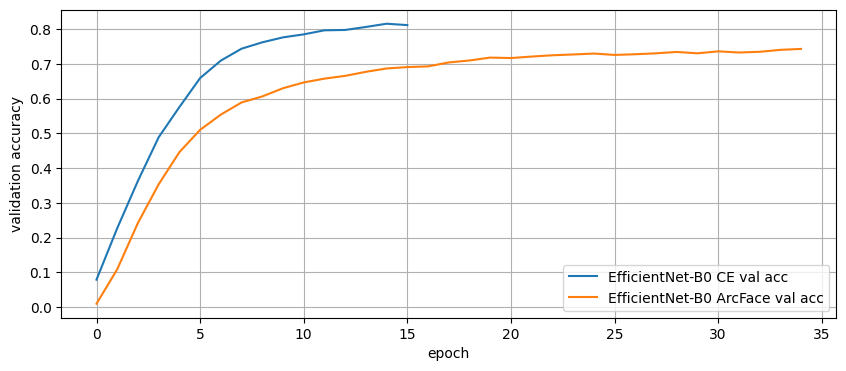

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_ce["val_acc"], label="EfficientNet-B0 CE val acc")
plt.plot(history_arc["val_acc"], label="EfficientNet-B0 ArcFace val acc")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.grid()
plt.show()

# Качество эмбеддингов

Тут я хотела показать, что несмотря на то, что качество с ArcFace немного меньше, чем если просто рассматривать Cross Entropy, **эмбеддинги лучше различают пары одного/разных людей**.

Высчитала качество embeddings через **косинусное сходство (cosine similarity)**.

In [58]:
from sklearn.metrics import roc_auc_score, roc_curve
from itertools import combinations

ce_eval_model = EfficientNetClassifierCE(
    num_classes=500,
    embedding_dim=512,
    pretrained=False,
).to(device)

ce_eval_model.load_state_dict(
    torch.load(PROJECT_DIR / "ce_efficientnet_b0_best.pt", map_location=device)
)
ce_eval_model.eval()


arc_eval_model = EfficientNetClassifierArcFace(
    num_classes=num_classes,
    embedding_dim=512,
    pretrained=False,
).to(device)

arc_eval_model.load_state_dict(
    torch.load(PROJECT_DIR / "arcface_efficientnet_b0_best.pt", map_location=device)
)
arc_eval_model.eval()

EfficientNetClassifierArcFace(
  (embedding_model): EfficientNetEmbeddingModel(
    (backbone): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32

Извлекаю эмбеддинги:

In [59]:
@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()

    all_embeddings = []
    all_labels = []

    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)

        embeddings = model.embedding_model(imgs)
        embeddings = F.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels)

    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0).numpy()

    return embeddings, labels

In [60]:
ce_embeddings, val_labels = extract_embeddings(
    ce_eval_model,
    val_loader,
    device,
)

arc_embeddings, _ = extract_embeddings(
    arc_eval_model,
    val_loader,
    device,
)

100%|██████████| 47/47 [00:08<00:00,  5.58it/s]


Делаю пары: same person и different people

In [61]:
def make_verification_pairs(labels, random_state=42):
    rng = np.random.default_rng(random_state)

    labels = np.asarray(labels)
    label_to_indices = {}

    for index, label in enumerate(labels):
        label_to_indices.setdefault(label, []).append(index)

    positive_pairs = []

    for label, indices in label_to_indices.items():
        if len(indices) >= 2:
            positive_pairs.extend(list(combinations(indices, 2)))

    positive_pairs = np.array(positive_pairs)

    negative_pairs = []

    while len(negative_pairs) < len(positive_pairs):
        i, j = rng.choice(len(labels), size=2, replace=False)

        if labels[i] != labels[j]:
            negative_pairs.append((i, j))

    negative_pairs = np.array(negative_pairs)

    pairs = np.concatenate([positive_pairs, negative_pairs], axis=0)

    pair_labels = np.concatenate([
        np.ones(len(positive_pairs)),
        np.zeros(len(negative_pairs)),
    ])

    return pairs, pair_labels

In [62]:
pairs, pair_labels = make_verification_pairs(val_labels)

print("positive pairs:", int(pair_labels.sum()))
print("negative pairs:", int((1 - pair_labels).sum()))

positive pairs: 7524
negative pairs: 7524


Смотрю качество:

In [63]:
def evaluate_embedding_quality(embeddings, pairs, pair_labels):
    similarities = []

    for i, j in pairs:
        sim = F.cosine_similarity(
            embeddings[i].unsqueeze(0),
            embeddings[j].unsqueeze(0),
        ).item()

        similarities.append(sim)

    similarities = np.array(similarities)

    auc = roc_auc_score(pair_labels, similarities)

    fpr, tpr, thresholds = roc_curve(pair_labels, similarities)
    best_index = np.argmax(tpr - fpr)
    best_threshold = thresholds[best_index]

    predictions = similarities >= best_threshold
    best_accuracy = (predictions == pair_labels).mean()

    same_scores = similarities[pair_labels == 1]
    different_scores = similarities[pair_labels == 0]

    return {
        "similarities": similarities,
        "auc": auc,
        "best_threshold": best_threshold,
        "best_accuracy": best_accuracy,
        "same_mean": same_scores.mean(),
        "different_mean": different_scores.mean(),
        "gap": same_scores.mean() - different_scores.mean(),
        "fpr": fpr,
        "tpr": tpr,
    }

In [64]:
ce_quality = evaluate_embedding_quality(
    ce_embeddings,
    pairs,
    pair_labels,
)

arc_quality = evaluate_embedding_quality(
    arc_embeddings,
    pairs,
    pair_labels,
)

summary_df = pd.DataFrame([
    {
        "model": "EfficientNet-B0 CE",
        "AUC": ce_quality["auc"],
        "best_accuracy": ce_quality["best_accuracy"],
        "same_mean": ce_quality["same_mean"],
        "different_mean": ce_quality["different_mean"],
        "gap": ce_quality["gap"],
    },
    {
        "model": "EfficientNet-B0 ArcFace",
        "AUC": arc_quality["auc"],
        "best_accuracy": arc_quality["best_accuracy"],
        "same_mean": arc_quality["same_mean"],
        "different_mean": arc_quality["different_mean"],
        "gap": arc_quality["gap"],
    },
])

In [65]:
summary_df

,model,AUC,best_accuracy,same_mean,different_mean,gap
0,EfficientNet-B0 CE,0.95615,0.895534,0.325701,0.001322,0.324379
1,EfficientNet-B0 ArcFace,0.97399,0.936603,0.475237,-0.000686,0.475923


`gap` - это разрыв между средним cosine similarity для одного человека и средним cosine similarity для разных людей.

`gap = mean_cosine_same_person - mean_cosine_different_people`

Чем больше gap, тем лучше embedding-пространство разделяет людей.

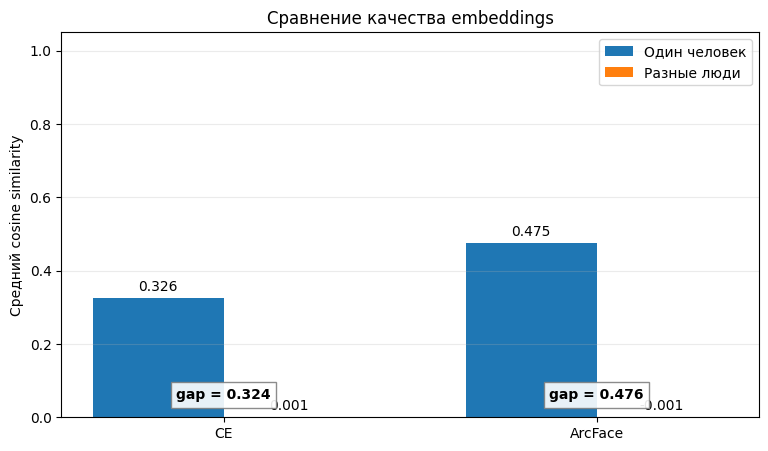

In [69]:
models = ["CE", "ArcFace"]

same_means = [
    ce_quality["same_mean"],
    arc_quality["same_mean"],
]

different_means = [
    ce_quality["different_mean"],
    arc_quality["different_mean"],
]

gaps = [
    ce_quality["gap"],
    arc_quality["gap"],
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width / 2, same_means, width, label="Один человек")

plt.bar(x + width / 2, different_means, width, label="Разные люди")

plt.xticks(x, models)
plt.ylabel("Средний cosine similarity")
plt.title("Сравнение качества embeddings")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.25)
plt.legend()

for i in range(len(models)):
    plt.text(x[i] - width / 2, same_means[i] + 0.02, f"{same_means[i]:.3f}", ha="center")

    plt.text(x[i] + width / 2, different_means[i] + 0.02, f"{different_means[i]:.3f}", ha="center")

    plt.text(x[i], 0.05, f"gap = {gaps[i]:.3f}", ha="center", fontweight="bold", bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9))

plt.show()

**Вывод:** значение gap у ArcFace выше. ArcFace сформировал более качественное embedding-пространство для задачи распознавания лиц.